# Question 1: Frailty Workflow

Ingest -> process -> analyze using raw headers exactly as in docx.


In [23]:
from pathlib import Path
import pandas as pd

CWD = Path.cwd()
ROOT = CWD if (CWD / 'data_raw').exists() else CWD.parent
DATA_RAW_DIR = ROOT / 'data_raw'
DATA_CLEAN_DIR = ROOT / 'data_clean'
REPORT_DIR = ROOT / 'reports'

DATA_CLEAN_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

print(f'Root: {ROOT}')
print(f'data_raw: {DATA_RAW_DIR}')
print(f'data_clean: {DATA_CLEAN_DIR}')
print(f'reports: {REPORT_DIR}')


Root: /Users/jainil/PycharmProjects/PrincipleOfDataScienceAssignments/Assignment_1/Question1
data_raw: /Users/jainil/PycharmProjects/PrincipleOfDataScienceAssignments/Assignment_1/Question1/data_raw
data_clean: /Users/jainil/PycharmProjects/PrincipleOfDataScienceAssignments/Assignment_1/Question1/data_clean
reports: /Users/jainil/PycharmProjects/PrincipleOfDataScienceAssignments/Assignment_1/Question1/reports


## Ingest

In [24]:
frailty_path = DATA_RAW_DIR / 'frailty_raw.csv'
frailty_raw = pd.read_csv(frailty_path)
print(f'Loaded rows: {len(frailty_raw)} from {frailty_path}')
frailty_raw


Loaded rows: 10 from /Users/jainil/PycharmProjects/PrincipleOfDataScienceAssignments/Assignment_1/Question1/data_raw/frailty_raw.csv


,Height,Weight,Age,Grip strength,Frailty
0,65.8,112,30,30,N
1,71.5,136,19,31,N
2,69.4,153,45,29,N
3,68.2,142,22,28,Y
4,67.8,144,29,24,Y
5,68.7,123,50,26,N
6,69.8,141,51,22,Y
7,70.1,136,23,20,Y
8,67.9,112,17,19,N
9,66.8,120,39,31,N


## Process

In [25]:
frailty.dtypes

Height            float64
Weight              int64
Age                 int64
Grip strength       int64
Frailty               str
Height_m          float64
Weight_kg         float64
BMI               float64
AgeGroup              str
Frailty_binary       int8
AgeGroup_<30         int8
AgeGroup_30-45       int8
AgeGroup_46-60       int8
AgeGroup_>60         int8
dtype: object

In [26]:
frailty = frailty_raw.copy()

# Unit standardization
frailty['Height_m'] = frailty['Height'] * 0.0254
frailty['Weight_kg'] = frailty['Weight'] * 0.45359237

# Feature engineering
frailty['BMI'] = (frailty['Weight_kg'] / (frailty['Height_m'] ** 2)).round(2)

def age_group(age):
    if age < 30:
        return "<30"
    if 30 <= age <= 45:
        return "30-45"   # <-- hyphen
    if 46 <= age <= 60:
        return "46-60"   # <-- hyphen
    return ">60"

frailty['AgeGroup'] = frailty['Age'].apply(age_group)

# Categorical -> numeric encoding
frailty['Frailty_binary'] = frailty['Frailty'].map({'Y': 1, 'N': 0}).astype('int8')

age_ohe = pd.get_dummies(frailty["AgeGroup"], prefix="AgeGroup")

expected_age_cols = ["AgeGroup_<30", "AgeGroup_30-45", "AgeGroup_46-60", "AgeGroup_>60"]
for col in expected_age_cols:
    if col not in age_ohe.columns:
        age_ohe[col] = 0

age_ohe = age_ohe[expected_age_cols].astype("int8")

frailty = pd.concat([frailty, age_ohe], axis=1)

processed_path = DATA_CLEAN_DIR / 'frailty_processed.csv'
frailty.to_csv(processed_path, index=False)
print(f'Saved processed data: {processed_path}')
frailty


Saved processed data: /Users/jainil/PycharmProjects/PrincipleOfDataScienceAssignments/Assignment_1/Question1/data_clean/frailty_processed.csv


,Height,Weight,Age,Grip strength,Frailty,Height_m,Weight_kg,BMI,AgeGroup,Frailty_binary,AgeGroup_<30,AgeGroup_30-45,AgeGroup_46-60,AgeGroup_>60
0,65.8,112,30,30,N,1.67132,50.802345,18.19,30-45,0,0,1,0,0
1,71.5,136,19,31,N,1.81610,61.688562,18.70,<30,0,1,0,0,0
2,69.4,153,45,29,N,1.76276,69.399633,22.33,30-45,0,0,1,0,0
3,68.2,142,22,28,Y,1.73228,64.410117,21.46,<30,1,1,0,0,0
4,67.8,144,29,24,Y,1.72212,65.317301,22.02,<30,1,1,0,0,0
5,68.7,123,50,26,N,1.74498,55.791862,18.32,46-60,0,0,0,1,0
6,69.8,141,51,22,Y,1.77292,63.956524,20.35,46-60,1,0,0,1,0
7,70.1,136,23,20,Y,1.78054,61.688562,19.46,<30,1,1,0,0,0
8,67.9,112,17,19,N,1.72466,50.802345,17.08,<30,0,1,0,0,0
9,66.8,120,39,31,N,1.69672,54.431084,18.91,30-45,0,0,1,0,0


## Analyze

In [27]:
numeric_cols = frailty.select_dtypes(include=['number']).columns
summary = frailty[numeric_cols].agg(['mean', 'median', 'std']).T.round(4)

corr_grip_frailty = frailty['Grip strength'].corr(frailty['Frailty_binary'])

lines = [
    '# Question 1 Findings',
    '',
    '## Summary Statistics',
    '',
    '| Column | Mean | Median | Std |',
    '|---|---:|---:|---:|'
]

for col, row in summary.iterrows():
    lines.append(f"| {col} | {row['mean']:.4f} | {row['median']:.4f} | {row['std']:.4f} |")

lines += [
    '',
    '## Strength vs Frailty',
    '',
    f"- Pearson correlation between `Grip strength` and `Frailty_binary`: **{corr_grip_frailty:.4f}**.",
    '- Interpretation: a negative value indicates higher grip strength tends to align with lower frailty in this sample.'
]

findings_path = REPORT_DIR / 'findings.md'
findings_path.write_text('\n'.join(lines), encoding='utf-8')

print(f'Saved report: {findings_path}')
print(f'Correlation (Grip strength vs Frailty_binary): {corr_grip_frailty:.4f}')
summary


Saved report: /Users/jainil/PycharmProjects/PrincipleOfDataScienceAssignments/Assignment_1/Question1/reports/findings.md
Correlation (Grip strength vs Frailty_binary): -0.4759


,mean,median,std
Height,68.6000,68.4500,1.6707
Weight,131.9000,136.0000,14.2318
Age,32.5000,29.5000,12.8604
Grip strength,26.0000,27.0000,4.5216
Height_m,1.7424,1.7386,0.0424
Weight_kg,59.8288,61.6886,6.4554
BMI,19.6820,19.1850,1.7810
Frailty_binary,0.4000,0.0000,0.5164
AgeGroup_<30,0.5000,0.5000,0.5270
AgeGroup_30-45,0.3000,0.0000,0.4830


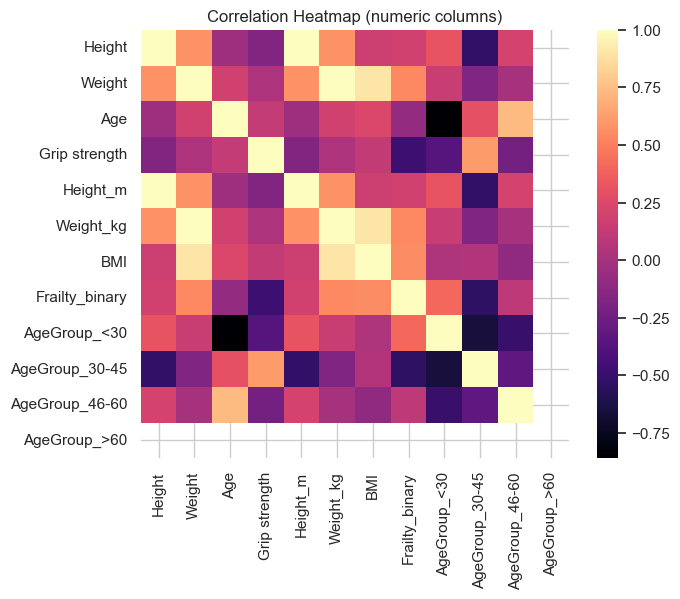

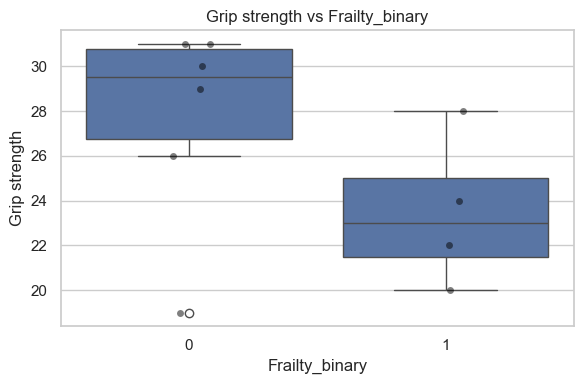

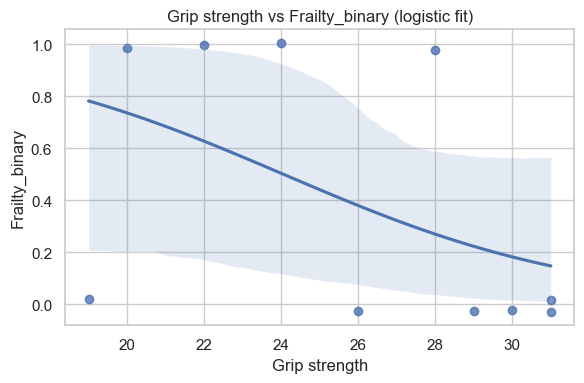

In [28]:
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

REPORT_DIR.mkdir(parents=True, exist_ok=True)

# ---- Choose numeric columns for EDA ----
numeric_cols = frailty.select_dtypes(include="number").columns.tolist()


# ---- 2) Correlation heatmap ----
plt.figure(figsize=(max(6, 0.6*len(numeric_cols)), max(4, 0.5*len(numeric_cols))))
corr = frailty[numeric_cols].corr(numeric_only=True)
sns.heatmap(corr, annot=False, cmap="magma", square=True, cbar=True)
plt.title("Correlation Heatmap (numeric columns)")
plt.tight_layout()
corr_path = REPORT_DIR / "figures/corr_heatmap.png"
plt.savefig(corr_path, dpi=200)
plt.show()
plt.close()

# ---- 3) Strength ↔ Frailty plots ----
# Prefer Grip_kg if present; else fallback to "Grip strength"
grip_col = "Grip_kg" if "Grip_kg" in frailty.columns else "Grip strength"

plt.figure(figsize=(6,4))
sns.boxplot(data=frailty, x="Frailty_binary", y=grip_col)
sns.stripplot(data=frailty, x="Frailty_binary", y=grip_col, color="black", alpha=0.5)
plt.title(f"{grip_col} vs Frailty_binary")
plt.tight_layout()
grip_box_path = REPORT_DIR / "figures/grip_vs_frailty_box.png"
plt.savefig(grip_box_path, dpi=200)
plt.show()
plt.close()

# Optional: regression-style plot (Frailty_binary is 0/1 so it's okay)
plt.figure(figsize=(6,4))
sns.regplot(data=frailty, x=grip_col, y="Frailty_binary", logistic=True, y_jitter=0.03)
plt.title(f"{grip_col} vs Frailty_binary (logistic fit)")
plt.tight_layout()
grip_reg_path = REPORT_DIR / "figures/grip_vs_frailty_logistic.png"
plt.savefig(grip_reg_path, dpi=200)
plt.show()
plt.close()

In [29]:
print('Generated files:')
print('-', DATA_RAW_DIR / 'frailty_raw.csv')
print('-', DATA_CLEAN_DIR / 'frailty_processed.csv')
print('-', REPORT_DIR / 'findings.md')


Generated files:
- /Users/jainil/PycharmProjects/PrincipleOfDataScienceAssignments/Assignment_1/Question1/data_raw/frailty_raw.csv
- /Users/jainil/PycharmProjects/PrincipleOfDataScienceAssignments/Assignment_1/Question1/data_clean/frailty_processed.csv
- /Users/jainil/PycharmProjects/PrincipleOfDataScienceAssignments/Assignment_1/Question1/reports/findings.md
